In [1]:
#installed packages #pip install pandas numpy scikit-learn matplotlib seaborn jupyter

#now imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


In [29]:
#loading dataset , model , test split , metrics
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score , root_mean_squared_error


In [ ]:
#starting EDA - EXploratory Data Analysis
#creating dataframe

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

df.head(10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
#EDA next step - checking for missing values 

df.isnull().sum()

#no missing values so no data cleaning 

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [ ]:
#lets see any outliers and some calculations of data

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.corr()    

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [15]:
X = df.drop(columns='MedHouseVal')
y=df['MedHouseVal']

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

print(X_train.shape)
print(y_train.shape)

#splitting of data done

(16512, 8)
(16512,)


In [17]:
#Feature Scaling
#creating scalar 

scalar= StandardScaler()

X_train_scaled=scalar.fit_transform(X_train)
X_tested_scaled=scalar.transform(X_test)

In [ ]:
#Creating and Evaluating the Models
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_tested_scaled)

In [53]:
mae=mean_absolute_error(y_test, y_pred_lr)   
rmse = root_mean_squared_error(y_test, y_pred_lr)
r2=r2_score(y_test,y_pred_lr) 

print('LinearRegression Model')
print(f"MAE:{mae:.3f}")
print(f"RMSE:{rmse:.3f}")
print(f"R2 SCORE:{r2:.3f}")

LinearRegression Model
MAE:0.533
RMSE:0.746
R2 SCORE:0.576


In [45]:
from sklearn.linear_model import Ridge

rr_model = Ridge(alpha=1.0)
rr_model.fit(X_train_scaled, y_train)

y_pred_rr = rr_model.predict(X_tested_scaled)

In [54]:
mae_ridge = mean_absolute_error(y_test, y_pred_rr)
rmse_ridge = root_mean_squared_error(y_test, y_pred_rr)
r2_ridge = r2_score(y_test, y_pred_rr)

print('RidgeRegression Model')
print(f"MAE: {mae_ridge:.3f}")
print(f"RMSE: {rmse_ridge:.3f}")
print(f"R² Score: {r2_ridge:.3f}")

RidgeRegression Model
MAE: 0.533
RMSE: 0.746
R² Score: 0.576


In [49]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)

tree_model.fit(X_train, y_train)   # Use X_train, not X_train_scaled

y_pred_tree = tree_model.predict(X_test)

In [58]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print('DecisionTreeRegressor Model')
print(f"MAE:{mae_tree:.3f}")
print(f"RMSE:{rmse_tree:.3f}")
print(f"R2 SCORE:{r2_tree:.3f}")

DecisionTreeRegressor Model
MAE:0.522
RMSE:0.724
R2 SCORE:0.600


In [61]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "MAE": [
        mae,
        mae_ridge,
        mae_tree
    ],
    "RMSE": [
        rmse,
        rmse_ridge,
        rmse_tree
    ],
    "R2 Score": [
        r2,
        r2_ridge,
        r2_tree
    ]
})

comparison_df = comparison_df.round(3)  #more clearer output
comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.533,0.746,0.576
1,Ridge Regression,0.533,0.746,0.576
2,Decision Tree,0.522,0.724,0.600


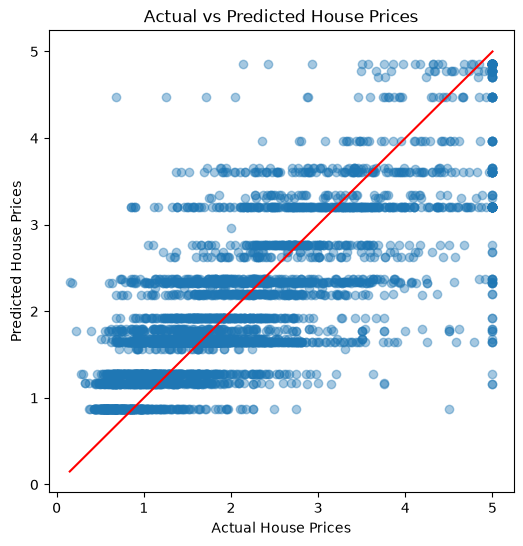

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_tree, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [64]:
print("Best Model:", best_model["Model"])

Best Model: Decision Tree


In [69]:
import joblib

joblib.dump(tree_model, "best_model.joblib")

['best_model.joblib']